In [46]:
from backend.utils.gmsh_function import *
from backend.src.radiation_algorithm.radiation_algorithm import *
from backend.utils.file_path import *
from backend.rwg.rwg6 import plot_surface_current_distribution

from backend.efield.efield1 import *
from backend.efield.efield2 import *
from backend.efield.efield3 import *

In [47]:
name = "strip_gap_radiation"
path = setup_save_file_paths(name)

In [48]:
mm = 1e-3
width = 20  * mm
length = 2000 * mm
# feed_point = np.array([0, length / 5, 0])
feed_point = np.array([0, 0, 0])

feed_point.shape

(3,)

In [49]:
light_speed = 3e8
frequency  = 75e6

# ── Automatic mesh & gap sizing ───────────────────────────────────────────────
# gap_fraction is a FIXED fraction of λ, independent of resolution.
# This prevents Z_in → ∞ divergence that occurs when gap_width ∝ mesh_size.
#
# Tuning guide:
#   resolution  : elements per λ  →  λ/20 (default), λ/30 (fine), λ/10 (coarse)
#   gap_fraction: W = gap_fraction × λ  →  0.15 (default, from convergence study)
#
# Constraint automatically enforced: mesh_size ≤ gap_width / 3
# (at least 3 edges inside the gap — required for stable integration)
# ─────────────────────────────────────────────────────────────────────────────
mesh_size, gap_width, wavelength = mesh_and_gap_parameters(
    frequency,
    resolution=25,       # λ/25 — change this to refine/coarsen the mesh
    gap_fraction=0.15,   # W = 0.15λ — do not reduce below 0.05λ
)

λ = 4.0000 m  |  mesh_size = λ/25 = 0.1600 m  |  gap = 0.15λ = 0.6000 m  |  N_edges_in_gap ≈ 3.8


In [50]:
gmsh.initialize()
model_name = "strip_antenna"

gmsh.model.add(model_name)
setup_performance_config()

strip_antenna = gmsh.model.occ.addRectangle(-width / 2, -length / 2, 0, width, length)

gmsh.model.occ.synchronize()

generate_and_save_mesh(path, mesh_size)

gmsh.finalize()

[PERFORMANCE] Gmsh configured to utilize 16 threads.
Geometry file saved in data/gmsh_files/strip_gap_radiation.brep successfully
--- Starting Mesh Optimization (Dim: 2) ---
--- Optimization Complete ---
Mesh file saved in data/gmsh_files/strip_gap_radiation.msh successfully


if new_feed: matrice_z, voltage, current, surface_current_density = radiation_algorithm(path.mat, frequency, feed_point, voltage_amplitude=1, port_type=0)
else: pass

In [51]:
*_, gap_currents, gap_voltages, impedances, feed_powers = radiation_algorithm(
    path, frequency, feed_point,
    excitation_unit_vector='y',
    gap_width=gap_width,
)

Number of points: 28
Number of triangles: 26
Number of edges: 25
Total input power P_in = 0.5*Re(V·I*) = 4.741647e-03 W
Port 0: P_in = 4.7416e-03 W  |  Q_in = 2.4671e-03 VAR  |  Z_in = 82.9841+43.1763j Ω


In [52]:
check_simulation_stability(impedances, frequency, mesh_size, gap_width)


[Stability Check]
  Port 0: Z_in = 82.98+43.18j Ω  — ✓ OK
  Gap check: gap/mesh = 3.8 ≥ 3 — ✓ OK
  Mesh check: λ/25 — ✓ in recommended range [λ/10, λ/100]
  Overall: ✓ PASS


True

## Guide des paramètres de simulation

`mesh_and_gap_parameters(frequency, resolution, gap_fraction)` calcule automatiquement `mesh_size` et `gap_width`.

### Pourquoi gap_fraction est fixe (fraction de λ) et non proportionnel au mesh ?

Si `gap_width = k × mesh_size` avec `mesh_size → 0`, la source de gap tend vers une source delta sur un conducteur 2D. La fonction de Green de ce problème présente une singularité logarithmique → **Z_in ∝ 1/mesh_size → ∞** (divergence garantie).

Avec `gap_width = gap_fraction × λ` fixé, Z_in converge vers une valeur physique finie.

### Règles de stabilité

| Condition | Effet |
|---|---|
| `gap/mesh < 0.67` | ❌ Aucune arête dans le gap — P_in = 0 |
| `gap/mesh < 3` | ⚠️ Sous-échantillonnage — Z_in instable |
| `gap/mesh ≥ 3` | ✅ Plateau stable |
| `mesh_size > λ/10` | ⚠️ Matrice Z imprécise |
| `mesh_size < λ/100` | ⚠️ Risque de mal-conditionnement |
| `gap_fraction > 0.20` | ⚠️ Excitation non-locale |

### Contrainte de cohérence

```
resolution ≥ n_edges_min / gap_fraction
```
Avec les valeurs par défaut (`gap_fraction=0.15`, `n_edges_min=3`) : `resolution ≥ 20` ✓

### Résultats de la convergence (75 MHz, λ = 4 m)

| gap_fraction | resolution | R_in [Ω] | Statut |
|---|---|---|---|
| 0.15λ | λ/20 | 87 | ✅ valide |
| 0.075λ | λ/40 | 85 | ✅ valide (converge) |
| 1.25λ *(ancien)* | λ/40 | 1123 | ❌ gap trop grand |

observationPoint = np.array([0, 0, 5])
calculate_electric_magnetic_field_at_point(path, observationPoint)

observationPoint = np.array([5, 0, 0])
calculate_electric_magnetic_field_at_point(path, observationPoint)

In [53]:
print("Calculating radiation intensity distribution over sphere surface...")
radiation_intensity_distribution_over_sphere_surface(path)

Calculating radiation intensity distribution over sphere surface...
Hollow sphere loaded: 5150 points, 10296 triangles.

[Antenna Results]
  Total Radiated Power : 0.004753704244371461 W
  Gain : 1.6508 (2.18 dBi)

[Power Budget]
  P_in  (0.5*Re(V·I*)) = 4.741647e-03 W
  P_rad (sphere integ.) = 4.753704e-03 W
  Raw efficiency       = 100.2543 %
  Port 0: Z_in = 82.9841+43.1763j Ω  |  R_in = 82.9841 Ω
  Total Efficiency     = 100.00 %
Data saved successfully to data/antennas_gain_power/strip_gap_radiation_gain_power.mat


MODE SELECTED: radiation


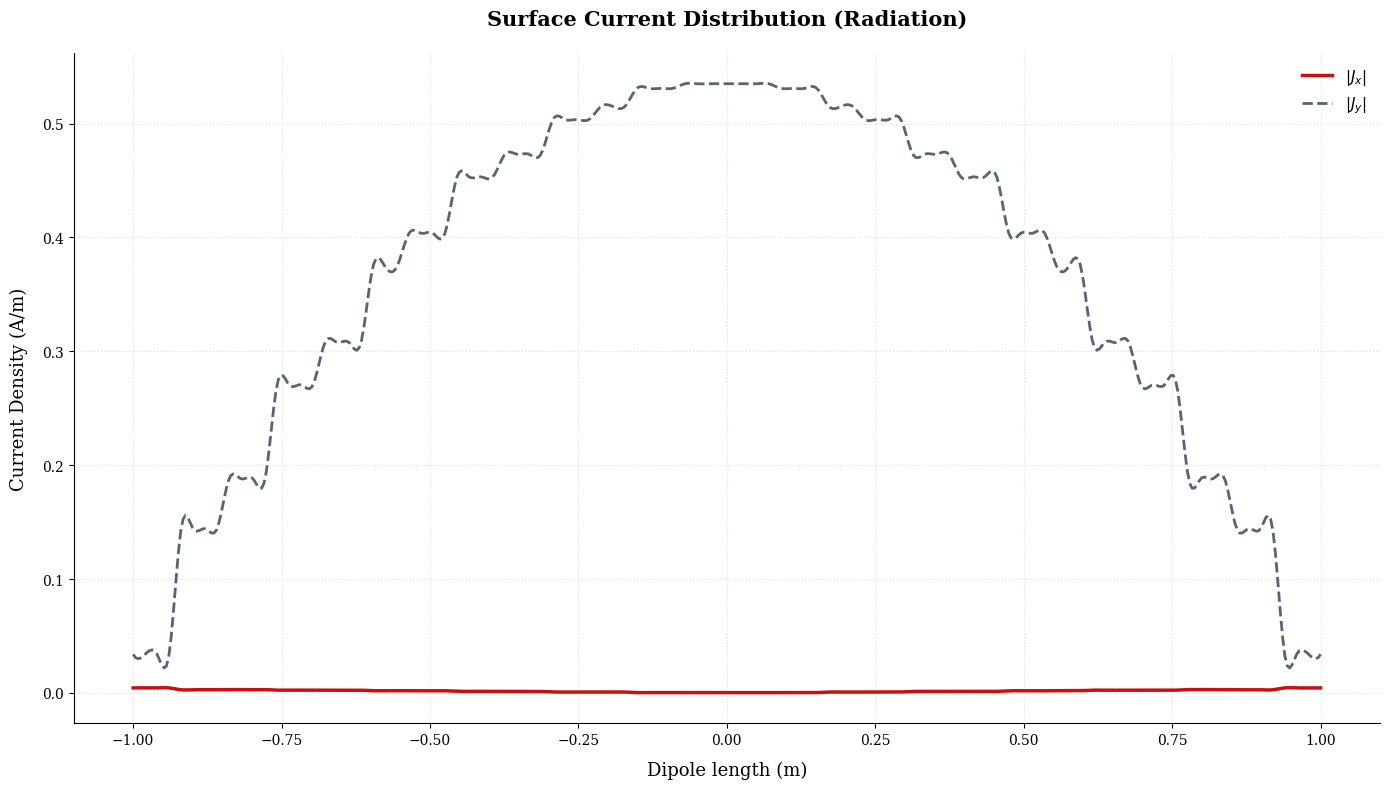

In [54]:
plot_surface_current_distribution(path, mode='radiation')